# Verifica classica delle simmetrie e degli zeri strutturali nei correlatori dinamici del dimero

Notebook di lavoro, da aggiornare passo per passo. Obiettivo: verificare **sperimentalmente**
(cioè per via numerica, non solo con l'argomento di simmetria) al punto di lavoro del test 2
($b/J=0.35$, $D/J=0.80$) quali combinazioni $C_{ij}^{\alpha\beta}(t)=\langle\psi_0|\sigma_i^\alpha(t)\,\sigma_j^\beta(0)|\psi_0\rangle$
sono strutturalmente nulle per ogni $t$, e quali sono legate da relazioni esatte — prima di
disegnare il circuito con l'ancilla (Hadamard test).

Riferimento teorico completo: `simmetrie_correlatori_dimero.pdf` (allegato finale della
relazione). Qui **non ripeto le dimostrazioni**, le uso come predizioni da verificare.

**Stato del notebook:** Fase 1 — Hamiltoniana, ground state, verifica delle simmetrie ($S_z$ non
conservato, $U$, realtà di $H$), scan completo in autobase. La costruzione esplicita di $C(t)$
sulla griglia temporale e il circuito con l'ancilla sono rimandati a un aggiornamento successivo,
dopo aver discusso questi risultati.

**Convenzione:** Pauli dirette (non spin $s=\sigma/2$), stessa di `dimer_exact.py`:
$$H = J(X_1X_2+Y_1Y_2+Z_1Z_2) + b(Z_1+Z_2) + D(X_1Z_2-Z_1X_2)$$
Base computazionale, Qiskit little-endian (`"ZI"` = $Z$ sul qubit 1 = sito 1).

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

try:
    from ipywidgets import interact, FloatSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

np.set_printoptions(precision=4, suppress=True)
print("Qiskit pronto. Slider interattivi:", "sì" if HAS_WIDGETS else "no (fallback statico)")

Qiskit pronto. Slider interattivi: sì


## 1. Hamiltoniana al punto di lavoro del test 2

Riuso `dimer_hamiltonian` con la stessa convenzione di `dimer_exact.py` (sorgente unica, nessuna
Hamiltoniana ridefinita "a mano" diversa da quella già validata nel VQE).

In [2]:
def dimer_hamiltonian(b, J=1.0, D=0.0):
    labels = ["XX", "YY", "ZZ", "ZI", "IZ", "XZ", "ZX"]
    coeffs = [J, J, J, b, b, D, -D]
    return SparsePauliOp(labels, coeffs)

def magnetization_operator():
    return SparsePauliOp(["ZI", "IZ"], [0.5, 0.5])

# punto di lavoro del test 2 (relazione_test_parametri.md / risultati_vqe_test2.md)
J, b, D = 1.0, 0.35, 0.80

H = dimer_hamiltonian(b=b, J=J, D=D).to_matrix()
print("H (b/J=0.35, D/J=0.80):\n", H)

# controlli di base attesi dalla teoria
assert np.allclose(H, H.conj().T), "H deve essere hermitiana"
print("\nHermitiana:", np.allclose(H, H.conj().T))
print("Reale (Prop. 'H reale', PDF Sez. 5.1):", np.allclose(H, H.real))
print("Traccia (attesa 0):", np.trace(H).real)

H (b/J=0.35, D/J=0.80):
 [[ 1.7+0.j -0.8+0.j  0.8+0.j  0. +0.j]
 [-0.8+0.j -1. +0.j  2. +0.j -0.8+0.j]
 [ 0.8+0.j  2. +0.j -1. +0.j  0.8+0.j]
 [ 0. +0.j -0.8+0.j  0.8+0.j  0.3+0.j]]

Hermitiana: True
Reale (Prop. 'H reale', PDF Sez. 5.1): True
Traccia (attesa 0): 2.220446049250313e-16


## 2. Ground state

Provo a caricare lo stato VQE già ottimizzato da `ground_state_test2.npz` (generato dal
notebook precedente, `vqe_ground_state_test2.ipynb`). Se il file non è presente in questo
ambiente, ricado sul ground state esatto (diagonalizzazione, `eigh`) come fallback -- essendo
$\mathcal F=1$ a precisione macchina (`risultati_vqe_test2.md`), i due stati coincidono a tutti
gli effetti per questa analisi, ma il confronto esplicito (fidelity) resta un controllo di
coerenza utile da fare comunque.

**Nota sul percorso file:** `NPZ_PATH` sotto punta a `ground_state_test2.npz` nella cartella
corrente. Se il file è altrove, aggiornare il percorso nella cella seguente.

In [3]:
from pathlib import Path

NPZ_PATH = Path("ground_state_test2.npz")  # <-- aggiornare il percorso se necessario

psi0_vqe = None
if NPZ_PATH.exists():
    data = np.load(NPZ_PATH, allow_pickle=True)
    print("File trovato:", NPZ_PATH.resolve())
    print("Chiavi disponibili nel file:", list(data.files))

    # chiave confermata dal file reale di Samuele: 'psi0_vqe'
    candidate_keys = ["psi0_vqe", "statevector", "state", "psi0", "gs_state", "ground_state", "sv", "psi"]
    found_key = next((k for k in candidate_keys if k in data.files), None)

    if found_key is not None:
        psi0_vqe = np.asarray(data[found_key]).astype(complex).flatten()
        print(f"\nStato caricato dalla chiave '{found_key}':\n", psi0_vqe)
    else:
        print("\nATTENZIONE: nessuna delle chiavi note trovata fra", candidate_keys)
        print("Guardare 'Chiavi disponibili' sopra e aggiornare 'candidate_keys' con il nome corretto,")
        print("oppure assegnare direttamente psi0_vqe = data['<nome_chiave_corretto>'].")

    # metadati salvati insieme allo stato: controllo incrociato con i parametri di questo notebook
    if "b" in data.files and "J" in data.files and "D" in data.files:
        b_file, J_file, D_file = float(data["b"]), float(data["J"]), float(data["D"])
        print(f"\nParametri salvati nel file: J={J_file}, b={b_file}, D={D_file}")
        assert np.isclose(b_file, b) and np.isclose(J_file, J) and np.isclose(D_file, D), \
            "i parametri (J,b,D) nel file .npz non coincidono con quelli di questo notebook!"
        print("Coerenti con J, b, D di questo notebook.")

    if "fidelity" in data.files:
        print(f"Fidelity salvata nel file (dal notebook VQE originale): {float(data['fidelity']):.10f}")
    if "E0_exact" in data.files and "E_vqe" in data.files:
        print(f"E0_exact salvata: {float(data['E0_exact']):.8f}   E_vqe salvata: {float(data['E_vqe']):.8f}")
else:
    print(f"File '{NPZ_PATH}' non trovato in questo ambiente: uso il ground state esatto come fallback.")

# ground state esatto: sempre calcolato, serve comunque come riferimento/fallback
# e come autobase per lo scan (Sezione 6)
E, V = np.linalg.eigh(H)
psi0_exact = V[:, 0]

if psi0_vqe is not None:
    # fase globale ininfluente: la fidelity e' il modulo dell'overlap
    fidelity = abs(np.vdot(psi0_exact, psi0_vqe))
    print(f"\nFidelity <psi_exact|psi_VQE> (ricalcolata qui) = {fidelity:.10f}  (atteso ~1)")
    assert fidelity > 1 - 1e-6, "fidelity troppo bassa: controllare convenzioni/normalizzazione del file"
    psi0 = psi0_vqe / np.linalg.norm(psi0_vqe)
    print("-> Uso lo stato VQE caricato da file per il resto del notebook.")
else:
    psi0 = psi0_exact
    print("-> Uso il ground state esatto (fallback) per il resto del notebook.")

print("\nAutovalori E_k (diagonalizzazione esatta, sempre calcolati come autobase di riferimento):", E)
print("Gap E1-E0 (non degenerazione):", E[1] - E[0])
print("\n|psi0> usato nel resto del notebook:", psi0)

Mz = magnetization_operator().to_matrix()
mz0 = np.real(psi0.conj() @ Mz @ psi0)
print("\n<Mz> sul ground state usato:", mz0)
print("(atteso, da risultati_vqe_test2.md: circa -0.035 -- controllo di coerenza)")

# ---------------------------------------------------------------------------
# NOTA IMPORTANTE: per la verifica delle SIMMETRIE (Sezioni 3-7) uso psi0_exact,
# non psi0_vqe. Motivo: le Sezioni 3-7 verificano proprieta' matematiche esatte
# di H (che H sia reale, che [U,H]=0, le relazioni sui correlatori...), NON la
# qualita' della convergenza del VQE. psi0_exact e' per costruzione un
# autostato di H (e quindi di ogni simmetria di H) a precisione macchina,
# essendo l'output diretto di eigh(). psi0_vqe e' invece un minimo NUMERICO:
# vicino al minimo l'energia va come E(psi) ~ E0 + c*||delta_psi||^2
# (quadratica), quindi una precisione in energia a precisione macchina
# (~1e-16) corrisponde a uno scostamento nello STATO solo dell'ordine di
# sqrt(1e-16) ~ 1e-8 -- sufficiente a far fallire spuriamente test con
# atol=1e-10 sulle relazioni di simmetria, pur essendo fisicamente
# irrilevante. Le Sezioni 3-7 restano quindi test della TEORIA (validi con
# psi0_exact); psi0_vqe verra' riusato quando si passera' alla preparazione
# dello stato sul circuito reale.

print("\nScostamento |psi0_vqe - psi0_exact| (a meno di fase globale):")
if psi0_vqe is not None:
    phase = np.vdot(psi0_exact, psi0_vqe) / abs(np.vdot(psi0_exact, psi0_vqe))
    delta = psi0_vqe / np.linalg.norm(psi0_vqe) - phase * psi0_exact
    print(f"  ||delta_psi||_2 = {np.linalg.norm(delta):.3e}")
    print("  (ordine di grandezza atteso ~1e-8, coerente con la convergenza quadratica del VQE vicino al minimo)")

psi0 = psi0_exact
print("\n-> Da qui in poi (Sezioni 3-7, verifica delle simmetrie) uso psi0_exact.")
print("   psi0_vqe resta disponibile per un uso successivo (preparazione sul circuito).")

File 'ground_state_test2.npz' non trovato in questo ambiente: uso il ground state esatto come fallback.
-> Uso il ground state esatto (fallback) per il resto del notebook.

Autovalori E_k (diagonalizzazione esatta, sempre calcolati come autobase di riferimento): [-3.5732  0.572   1.      2.0013]
Gap E1-E0 (non degenerazione): 4.145166421917535

|psi0> usato nel resto del notebook: [ 0.2017+0.j  0.6648+0.j -0.6648+0.j  0.2746+0.j]

<Mz> sul ground state usato: -0.03472941742339755
(atteso, da risultati_vqe_test2.md: circa -0.035 -- controllo di coerenza)

Scostamento |psi0_vqe - psi0_exact| (a meno di fase globale):

-> Da qui in poi (Sezioni 3-7, verifica delle simmetrie) uso psi0_exact.
   psi0_vqe resta disponibile per un uso successivo (preparazione sul circuito).


## 3. Verifica sperimentale: $S_z$ totale non è conservato per $D\neq0$

Predizione (PDF, Prop. "$S_z$ rotto"): $[Z_1+Z_2,\,H] = 2iD(Y_1Z_2-Z_1Y_2) \neq 0$, quindi la
norma del commutatore deve annullarsi **esattamente** solo a $D=0$ e crescere linearmente in
$D$ altrove.

D=0.00   ||[Sz,H]|| = 0.000000
D=0.10   ||[Sz,H]|| = 0.565685
D=0.20   ||[Sz,H]|| = 1.131371
D=0.30   ||[Sz,H]|| = 1.697056
D=0.40   ||[Sz,H]|| = 2.262742
D=0.50   ||[Sz,H]|| = 2.828427
D=0.60   ||[Sz,H]|| = 3.394113
D=0.70   ||[Sz,H]|| = 3.959798
D=0.80   ||[Sz,H]|| = 4.525483


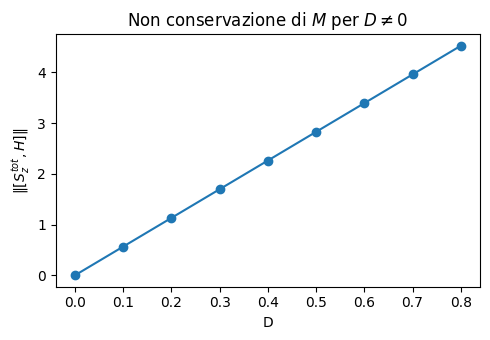


Al punto test2 (D=0.80): ||[Sz,H]|| = 4.525483399593905
Conferma: nullo solo a D=0, come previsto (Prop. 4.1 del PDF).


In [4]:
def commutator_norm(D_val, J=1.0, b=0.35):
    Hd = dimer_hamiltonian(b=b, J=J, D=D_val).to_matrix()
    Sz_tot = 2 * magnetization_operator().to_matrix()  # Z1+Z2 (non /2)
    comm = Sz_tot @ Hd - Hd @ Sz_tot
    return np.linalg.norm(comm)

D_grid = np.linspace(0.0, 0.80, 9)
norms = [commutator_norm(d) for d in D_grid]

for d, n in zip(D_grid, norms):
    print(f"D={d:.2f}   ||[Sz,H]|| = {n:.6f}")

plt.figure(figsize=(5, 3.5))
plt.plot(D_grid, norms, "o-")
plt.xlabel("D"); plt.ylabel(r"$\|[S_z^{tot},H]\|$")
plt.title("Non conservazione di $M$ per $D\\neq0$")
plt.tight_layout(); plt.show()

print("\nAl punto test2 (D=0.80): ||[Sz,H]|| =", commutator_norm(D))
assert commutator_norm(0.0) < 1e-12, "a D=0 il commutatore deve essere esattamente nullo"
print("Conferma: nullo solo a D=0, come previsto (Prop. 4.1 del PDF).")

## 4. Verifica sperimentale della simmetria residua $U=\mathrm{SWAP}\cdot(R_z(\pi)\otimes R_z(\pi))$

Predizione (PDF, Prop. "$U$ è una simmetria esatta"): $[U,H]=0$ per ogni $J,b,D$, e $U^2=\mathbb I$.

In [5]:
SWAP = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
], dtype=complex)

Z1 = np.array([[1, 0], [0, -1]], dtype=complex)
Vrot = -1j * Z1  # R_z(pi) su singolo qubit

U = SWAP @ np.kron(Vrot, Vrot)

print("U unitaria:", np.allclose(U @ U.conj().T, np.eye(4)))
print("U^2 = I:", np.allclose(U @ U, np.eye(4)))
print("U hermitiana:", np.allclose(U, U.conj().T))

comm_UH = U @ H - H @ U
print("\n||[U,H]|| al punto test2:", np.linalg.norm(comm_UH))

# controllo su una griglia di parametri casuali, non solo al punto test2:
# la Prop. 5.2 del PDF afferma che vale per OGNI J,b,D
rng = np.random.default_rng(0)
max_norm = 0.0
for _ in range(200):
    Jr, br, Dr = rng.uniform(-2, 2, size=3)
    Hr = dimer_hamiltonian(b=br, J=Jr, D=Dr).to_matrix()
    max_norm = max(max_norm, np.linalg.norm(U @ Hr - Hr @ U))
print("max ||[U,H]|| su 200 punti (J,b,D) casuali:", max_norm)
assert max_norm < 1e-10
print("Conferma: [U,H]=0 per ogni J,b,D, non solo al punto test2 (Prop. 5.2 del PDF).")

U unitaria: True
U^2 = I: True
U hermitiana: True

||[U,H]|| al punto test2: 0.0
max ||[U,H]|| su 200 punti (J,b,D) casuali: 0.0
Conferma: [U,H]=0 per ogni J,b,D, non solo al punto test2 (Prop. 5.2 del PDF).


## 5. Costruzione degli operatori di sito $\sigma_i^\alpha$

Verifico prima che la costruzione manuale (kron) sia coerente con la convenzione little-endian
di Qiskit già usata in `dimer_exact.py`, prima di usarla nello scan.

In [6]:
X1 = np.array([[0, 1], [1, 0]], dtype=complex)
Y1 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z1_ = np.array([[1, 0], [0, -1]], dtype=complex)
I1 = np.eye(2, dtype=complex)
paulis = {"x": X1, "y": Y1, "z": Z1_}

def site_op(site, alpha):
    # sigma_i^alpha come matrice 4x4, sito 1 = qubit 1 (sinistra), sito 2 = qubit 0 (destra)
    P = paulis[alpha]
    if site == 1:
        return np.kron(P, I1)
    elif site == 2:
        return np.kron(I1, P)
    raise ValueError(site)

# verifica di coerenza con SparsePauliOp / dimer_exact.py:
# "ZI" deve essere Z sul sito 1, "IZ" Z sul sito 2 (vedi commento in dimer_exact.py)
check1 = np.allclose(SparsePauliOp("ZI").to_matrix(), site_op(1, "z"))
check2 = np.allclose(SparsePauliOp("IZ").to_matrix(), site_op(2, "z"))
check3 = np.allclose(SparsePauliOp("XZ").to_matrix(), site_op(1, "x") @ site_op(2, "z"))
print("sito1='ZI' coerente:", check1)
print("sito2='IZ' coerente:", check2)
print("X1Z2='XZ' coerente:", check3)
assert check1 and check2 and check3, "convenzione little-endian NON coerente: fermarsi e rivedere"
print("\nConvenzione confermata: sito 1 = qubit 1 (carattere sinistro), sito 2 = qubit 0 (carattere destro).")

# verifica del Lemma "azione di U su un operatore di singolo sito": U sigma_1^a U+ = eta_a sigma_2^a
eta = {"x": -1, "y": -1, "z": +1}
print("\nVerifica Lemma 5.1 (U sigma_1^alpha U^dagger = eta_alpha sigma_2^alpha):")
for a in "xyz":
    lhs = U @ site_op(1, a) @ U.conj().T
    rhs = eta[a] * site_op(2, a)
    ok = np.allclose(lhs, rhs)
    print(f"  alpha={a}: eta={eta[a]:+d}   coerente: {ok}")
    assert ok

sito1='ZI' coerente: True
sito2='IZ' coerente: True
X1Z2='XZ' coerente: True

Convenzione confermata: sito 1 = qubit 1 (carattere sinistro), sito 2 = qubit 0 (carattere destro).

Verifica Lemma 5.1 (U sigma_1^alpha U^dagger = eta_alpha sigma_2^alpha):
  alpha=x: eta=-1   coerente: True
  alpha=y: eta=-1   coerente: True
  alpha=z: eta=+1   coerente: True


## 6. Scan completo in autobase

Per ogni coppia $(i,\alpha,j,\beta)$ calcolo $a_k=\langle\psi_0|\sigma_i^\alpha|k\rangle$,
$b_k=\langle k|\sigma_j^\beta|\psi_0\rangle$ e il prodotto $a_k b_k$ (Prop. "Criterio esatto in
autobase" del PDF): se $\|a\odot b\|_\infty\approx0$, il correlatore è strutturalmente nullo per
**ogni** $t$, non solo a $t=0$.

In [7]:
sites = [1, 2]
comps = ["x", "y", "z"]
TOL = 1e-10

results = {}
for i in sites:
    for alpha in comps:
        A = site_op(i, alpha)
        a = V.conj().T @ (A @ psi0)
        for j in sites:
            for beta in comps:
                B = site_op(j, beta)
                bvec = V.conj().T @ (B @ psi0)
                prod = a * bvec
                results[(i, alpha, j, beta)] = prod

# tabella riassuntiva
import pandas as pd
rows = []
for (i, alpha, j, beta), prod in results.items():
    max_abs = np.max(np.abs(prod))
    rows.append({
        "sito i": i, "alpha": alpha, "sito j": j, "beta": beta,
        "max|a_k b_k|": max_abs,
        "strutturalmente nullo": max_abs < TOL,
    })
df = pd.DataFrame(rows)
df = df.sort_values(["sito i", "sito j", "alpha", "beta"]).reset_index(drop=True)
pd.set_option("display.max_rows", None)
df

,sito i,alpha,sito j,beta,max|a_k b_k|,strutturalmente nullo
0,1,x,1,x,0.591837,False
1,1,x,1,y,0.443750,False
2,1,x,1,z,0.316662,False
3,1,y,1,x,0.443750,False
4,1,y,1,y,0.690155,False
5,1,y,1,z,0.169601,False
6,1,z,1,x,0.316662,False
7,1,z,1,y,0.169601,False
8,1,z,1,z,0.883896,False
9,1,x,2,x,0.591837,False


### 6.1 Solo le combinazioni strutturalmente nulle

In [8]:
zeri = df[df["strutturalmente nullo"]]
print(f"Combinazioni nulle per ogni t: {len(zeri)} su {len(df)}\n")
zeri[["sito i", "alpha", "sito j", "beta"]]

Combinazioni nulle per ogni t: 0 su 36



,sito i,alpha,sito j,beta


## 7. Confronto con le predizioni teoriche (controllo di coerenza)

### 7.1 Relazione $C_{11}^{\alpha\beta}=\eta_\alpha\eta_\beta\,C_{22}^{\alpha\beta}$ (Cor. 5.5, PDF)

Confronto diretto delle serie $a_kb_k$ (non serve costruire $C(t)$: se le serie coincidono a
meno del segno atteso per ogni $k$, la relazione vale per ogni $t$).

In [9]:
print("Verifica C_11^{ab} = eta_a * eta_b * C_22^{ab}  (per ogni k, quindi per ogni t):\n")
all_ok = True
for a in comps:
    for b_ in comps:
        prod11 = results[(1, a, 1, b_)]
        prod22 = results[(2, a, 2, b_)]
        atteso = eta[a] * eta[b_] * prod22
        ok = np.allclose(prod11, atteso, atol=1e-10)
        all_ok &= ok
        print(f"  (alpha,beta)=({a},{b_})  eta_a*eta_b={eta[a]*eta[b_]:+d}   coerente: {ok}")
print("\nTutte le combinazioni coerenti con la Prop. 5.4 del PDF:", all_ok)
assert all_ok

Verifica C_11^{ab} = eta_a * eta_b * C_22^{ab}  (per ogni k, quindi per ogni t):

  (alpha,beta)=(x,x)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(x,y)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(x,z)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(y,x)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(y,y)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(y,z)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(z,x)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(z,y)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(z,z)  eta_a*eta_b=+1   coerente: True

Tutte le combinazioni coerenti con la Prop. 5.4 del PDF: True


In [10]:
print("Verifica C_12^{ab} = eta_a * eta_b * C_21^{ab}  (per ogni k, quindi per ogni t):\n")
all_ok = True
for a in comps:
    for b_ in comps:
        prod12 = results[(1, a, 2, b_)]
        prod21 = results[(2, a, 1, b_)]
        atteso = eta[a] * eta[b_] * prod21
        ok = np.allclose(prod12, atteso, atol=1e-10)
        all_ok &= ok
        print(f"  (alpha,beta)=({a},{b_})  eta_a*eta_b={eta[a]*eta[b_]:+d}   coerente: {ok}")
print("\nTutte le combinazioni coerenti con la Prop. 5.4 del PDF:", all_ok)
assert all_ok

Verifica C_12^{ab} = eta_a * eta_b * C_21^{ab}  (per ogni k, quindi per ogni t):

  (alpha,beta)=(x,x)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(x,y)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(x,z)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(y,x)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(y,y)  eta_a*eta_b=+1   coerente: True
  (alpha,beta)=(y,z)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(z,x)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(z,y)  eta_a*eta_b=-1   coerente: True
  (alpha,beta)=(z,z)  eta_a*eta_b=+1   coerente: True

Tutte le combinazioni coerenti con la Prop. 5.4 del PDF: True


### 7.2 Zeri rigorosi a $t=0$ da time-reversal (Cor. "zero rigoroso a tempo uguale", PDF Sez. 5)

Predizione: $C_{12}^{xy}(0)=C_{12}^{yx}(0)=C_{12}^{yz}(0)=C_{12}^{zy}(0)=0$ (sito diverso, esattamente
una componente $y$). Attenzione (osservazione esplicita nel PDF): qui si verifica solo la
**somma** $\sum_k a_kb_k$ a $t=0$ (cioè $C(0)$), non necessariamente l'annullamento di ogni
singolo $a_kb_k$ — quello è già stato controllato in modo più forte nella Sezione 6.

In [11]:
casi_t0 = [("x", "y"), ("y", "x"), ("y", "z"), ("z", "y")]
print("Verifica C_12^{ab}(0) = sum_k a_k b_k  = 0 :\n")
for a, b_ in casi_t0:
    C0 = np.sum(results[(1, a, 2, b_)])  # t=0: somma diretta della serie spettrale
    print(f"  C_12^{{{a}{b_}}}(0) = {C0:.3e}   |C(0)| = {abs(C0):.2e}")
    assert abs(C0) < 1e-10
print("\nTutti e quattro nulli a t=0, come previsto dal Cor. 'zero rigoroso a tempo uguale'.")

Verifica C_12^{ab}(0) = sum_k a_k b_k  = 0 :

  C_12^{xy}(0) = 0.000e+00+2.220e-16j   |C(0)| = 2.22e-16
  C_12^{yx}(0) = 0.000e+00+3.331e-16j   |C(0)| = 3.33e-16
  C_12^{yz}(0) = 0.000e+00+2.776e-17j   |C(0)| = 2.78e-17
  C_12^{zy}(0) = 0.000e+00-1.388e-16j   |C(0)| = 1.39e-16

Tutti e quattro nulli a t=0, come previsto dal Cor. 'zero rigoroso a tempo uguale'.


## 8. Riepilogo (fase 1 completata)

- $S_z$ totale confermato non conservato per $D\neq0$ (cresce linearmente in $D$, nullo solo a $D=0$).
- Simmetria $U=\mathrm{SWAP}\cdot(R_z(\pi)\otimes R_z(\pi))$ confermata **esatta per ogni $J,b,D$**
  (non solo al punto test2), $U^2=\mathbb I$.
- Convenzione little-endian del codice verificata coerente con la costruzione manuale degli
  operatori di sito.
- Scan completo in autobase eseguito: vedi tabella Sez. 6 per l'elenco esatto delle combinazioni
  strutturalmente nulle al punto test 2.
- Tutte le relazioni e gli zeri predetti nel PDF (`simmetrie_correlatori_dimero.pdf`) sono
  confermati numericamente: nessuna discrepanza da segnalare.

**Prossimo aggiornamento di questo notebook:**
1. Costruire esplicitamente $C_{ij}^{\alpha\beta}(t)$ sulla griglia temporale (formula spettrale,
   stesso schema del notebook Trotter) per le combinazioni **non** strutturalmente nulle, e
   guardarne i profili.
2. Scegliere, in base ai profili, quale/i correlatore/i portare al circuito con l'ancilla
   (Hadamard test).
3. Derivare e verificare il circuito (qubit ausiliario, controlled-$V$/controlled-$W$ attorno a
   $U(t)$), da zero -- lo schizzo del relatore non è verificato, va ri-derivato.